In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import zipfile
import os
import seaborn as sns
from PIL import Image

In [2]:
ZIP_PATH = "/content/drive/MyDrive/Srintami/new-dataset.zip"
DATASET_PATH = "/content"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
  for member in zip_ref.namelist():
    if not member.startswith('__MACOSX/'):
      zip_ref.extract(member, DATASET_PATH)

print("Berhasil di extract")

Berhasil di extract


In [3]:
data_path = "/content/new-dataset"

In [4]:
img_size = 224
batch_size = 16
epochs = 20
learning_rate = 0.001
seed = 123

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.3,
    subset="training",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.3,
    subset="validation",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = train_ds.class_names

print(class_names)

Found 2604 files belonging to 2 classes.
Using 1823 files for training.
Found 2604 files belonging to 2 classes.
Using 781 files for validation.
['bracing', 'insulator']


In [6]:
temp_batches = tf.data.experimental.cardinality(temp_ds)
val_size = temp_batches // 2
val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

train_ds = train_ds.map(
    lambda x, y: (
        data_augmentation(x, training=True),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [8]:
Autotune = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=Autotune)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(buffer_size=Autotune)
)

test_ds = (
    test_ds
    .cache()
    .prefetch(buffer_size=Autotune)
)

In [9]:
def count_classes(dataset, class_names):
    class_counts = {name: 0 for name in class_names}
    for _, labels in dataset:
        for label in labels.numpy():
            class_counts[class_names[label]] += 1
    return class_counts

print('Class distribution in training set:')
train_class_counts = count_classes(train_ds, class_names)
for class_name, count in train_class_counts.items():
    print(f"  {class_name}: {count} images")

print('\nClass distribution in validation set:')
val_class_counts = count_classes(val_ds, class_names)
for class_name, count in val_class_counts.items():
    print(f"  {class_name}: {count} images")

print('\nClass distribution in test set:')
test_class_counts = count_classes(test_ds, class_names)
for class_name, count in test_class_counts.items():
    print(f"  {class_name}: {count} images")

Class distribution in training set:
  bracing: 924 images
  insulator: 899 images

Class distribution in validation set:
  bracing: 189 images
  insulator: 195 images

Class distribution in test set:
  bracing: 210 images
  insulator: 187 images


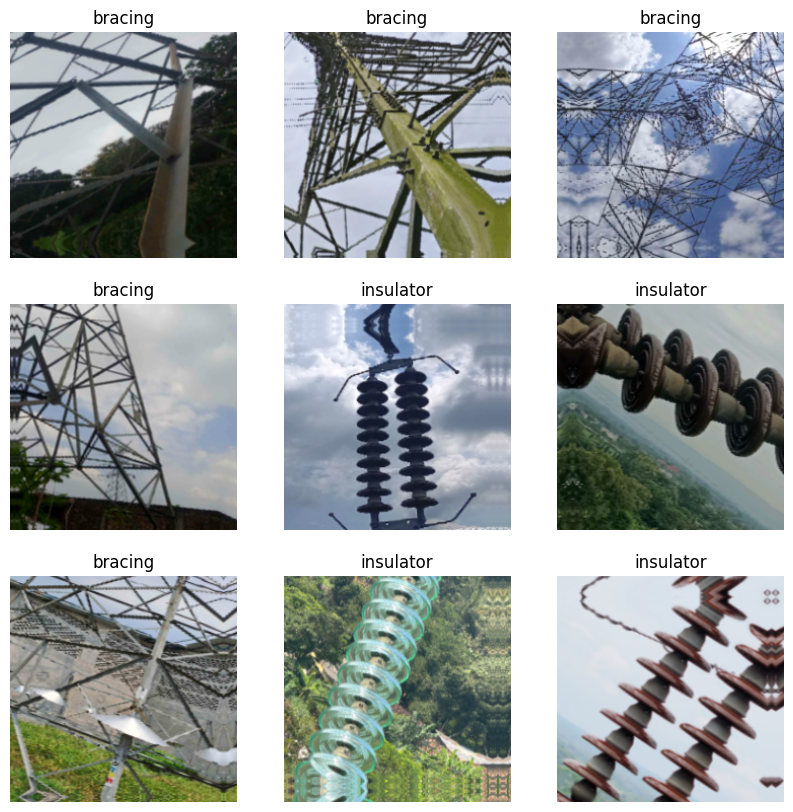

In [10]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [11]:
base_model = tf.keras.applications.EfficientNetB0(input_shape=(img_size, img_size, 3),
                                                  include_top=False,
                                                  weights='imagenet')

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.Input(shape=(img_size, img_size, 3)),
    # data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(2, activation='softmax')
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile (
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9468 - loss: 0.1527 - val_accuracy: 0.9792 - val_loss: 0.0597
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9748 - loss: 0.0702 - val_accuracy: 0.9844 - val_loss: 0.0439
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9786 - loss: 0.0535 - val_accuracy: 0.9896 - val_loss: 0.0370
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9879 - loss: 0.0396 - val_accuracy: 0.9896 - val_loss: 0.0341
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9901 - loss: 0.0353 - val_accuracy: 0.9844 - val_loss: 0.0528
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.9896 - loss: 0.0325 - val_accuracy: 0.9896 - val_loss: 0.0351
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9929 - loss: 0.0262 - val_accuracy: 0.9922 - val_loss: 0.0291
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9918 - loss: 0.0243 - val_accu

25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9798 - loss: 0.0442

Test Loss: 0.0442
Test Accuracy: 0.9798
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 997ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 981ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━

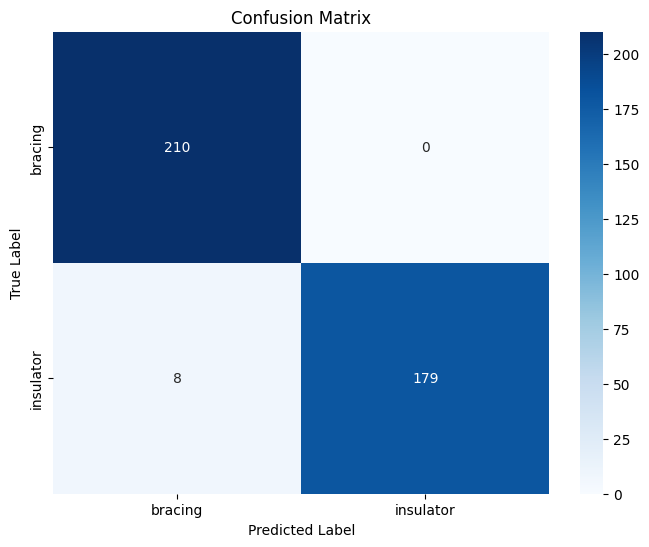

In [16]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

y_pred_raw = []
y_true = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_pred_raw.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_pred = np.array(y_pred_raw)
y_true = np.array(y_true)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Saving insulator13.jpeg to insulator13.jpeg
File upload "insulator13.jpeg"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


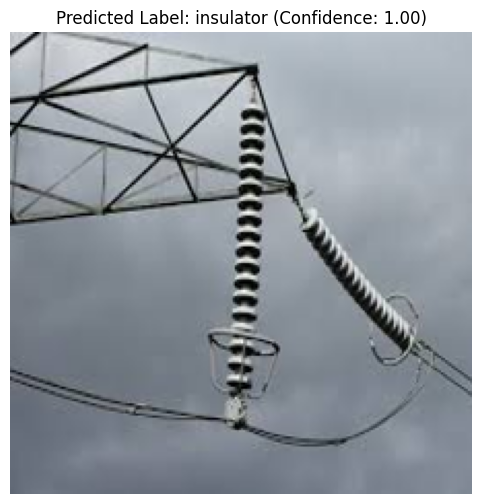

In [43]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('File upload "{name}"'.format(
      name=fn, length=len(uploaded[fn])))
  uploaded_image_path = fn
  break

if 'uploaded_image_path' in locals():
    try:
        img = Image.open(uploaded_image_path)

        img = img.resize((img_size, img_size))

        img_array = np.array(img)

        if img_array.ndim == 2:
            img_array = np.stack([img_array, img_array, img_array], axis=-1)
        elif img_array.shape[-1] == 4:
            img_array = img_array[..., :3]

        img_for_prediction = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_for_prediction)
        predicted_class_index = np.argmax(predictions[0])
        predicted_class_name = class_names[predicted_class_index]
        confidence = np.max(predictions[0])

        plt.figure(figsize=(6, 6))
        plt.imshow(img_array.astype('uint8'))
        plt.title(f"Predicted Label: {predicted_class_name} (Confidence: {confidence:.2f})")
        plt.axis('off')
        plt.show()

        # print(f"Raw predictions: {predictions[0]}")

    except Exception as e:
        print(f"An error occurred during image processing or prediction: {e}")
else:
    print("Please upload an image to proceed.")

In [ ]:
model.save_weights("model.weights.h5")

In [44]:
model.save('image_classification_model.h5', save_format='h5')

In [45]:
model.save('image_classification.keras')

In [ ]:
from google.colab import files

files.download('model.weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_244')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139654795378768: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139655023590096: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139655026886800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655026886224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655026887376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655026888144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655026888720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655026886992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655026887184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655026888528: TensorSpec(shape=(), dtype=tf.resource, name=None)

In [47]:
import shutil

shutil.make_archive(
    "saved_model",
    "zip",
    "saved_model"
)

'/content/saved_model.zip'